# 03: Single-Signal IC Analysis

**Thin client** over `src/factors/evaluate.py`. Measures each feature's standalone
Information Coefficient — the baseline the ML model must beat — and checks signs
against factor theory.

> This quick run uses ~30 tickers, so magnitudes are noisy; we're validating the
> machinery and sign direction, not drawing conclusions.

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt

from src.data import cache
from src.factors import evaluate
from src.factors.panel import _feature_list

plt.style.use('seaborn-v0_8-whitegrid')
p = cache.load('panel.parquet')

# Stock-level signals only (macro is constant across the cross-section).
signals = [f for f in _feature_list() if f not in ('yield_curve', 'vix', 'hy_spread')]
report = evaluate.signal_report(p, signals)
report[['ic_mean', 'ic_ir', 't_stat', 'hit_rate', 'n_months']].round(3)

,ic_mean,ic_ir,t_stat,hit_rate,n_months
revenue_growth_yoy,0.074,0.246,2.250,0.619,84.0
profit_margin,0.053,0.171,1.635,0.549,91.0
momentum_6_1,0.047,0.161,2.219,0.558,190.0
earnings_yield,0.040,0.136,1.791,0.546,174.0
momentum_12_2,0.032,0.109,1.500,0.521,190.0
accruals,0.027,0.089,1.187,0.514,177.0
ev_ebitda_inv,0.027,0.088,1.161,0.568,176.0
size_log_mktcap,0.002,0.007,0.087,0.466,176.0
gross_margin,-0.003,-0.005,-0.038,0.460,63.0
roe,-0.003,-0.009,-0.114,0.503,177.0


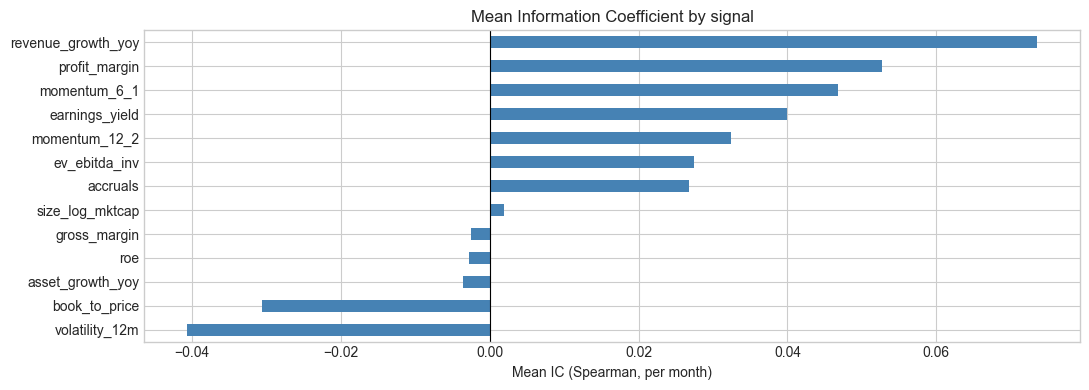

In [2]:
# IC bar chart
fig, ax = plt.subplots(figsize=(11, 4))
report['ic_mean'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Mean Information Coefficient by signal')
ax.set_xlabel('Mean IC (Spearman, per month)')
plt.tight_layout(); plt.show()

## Sign sanity vs. theory

Expected directions: momentum **+**, value (earnings yield / book-to-price / EV-EBITDA) **+**,
profitability (ROE, margins) **+**, volatility **−** (low-vol), size **−** (small-cap premium),
accruals **−**, asset growth **−** (conservative investment).

In [3]:
expected_sign = {
    'momentum_12_2': 1, 'momentum_6_1': 1, 'earnings_yield': 1, 'book_to_price': 1,
    'ev_ebitda_inv': 1, 'roe': 1, 'gross_margin': 1, 'profit_margin': 1,
    'volatility_12m': -1, 'size_log_mktcap': -1, 'accruals': -1, 'asset_growth_yoy': -1,
    'revenue_growth_yoy': 0,
}
chk = report[['ic_mean']].copy()
chk['expected'] = pd.Series(expected_sign)
chk['actual_sign'] = chk['ic_mean'].apply(lambda x: 1 if x > 0 else -1)
chk['matches'] = (chk['expected'] == 0) | (chk['expected'] == chk['actual_sign'])
print(chk.round(3).to_string())
print(chk.round(3).to_string())
print(f'\nSigns matching theory: {chk["matches"].mean()*100:.0f}% (small-sample noise expected)')

                    ic_mean  expected  actual_sign  matches
revenue_growth_yoy    0.074         0            1     True
profit_margin         0.053         1            1     True
momentum_6_1          0.047         1            1     True
earnings_yield        0.040         1            1     True
momentum_12_2         0.032         1            1     True
accruals              0.027        -1            1    False
ev_ebitda_inv         0.027         1            1     True
size_log_mktcap       0.002        -1            1    False
gross_margin         -0.003         1           -1    False
roe                  -0.003         1           -1    False
asset_growth_yoy     -0.004        -1           -1     True
book_to_price        -0.031         1           -1    False
volatility_12m       -0.041        -1           -1     True
                    ic_mean  expected  actual_sign  matches
revenue_growth_yoy    0.074         0            1     True
profit_margin         0.053         1   

## Quantile spread — does the top quantile out-earn the bottom?

Best signal by IC IR: revenue_growth_yoy


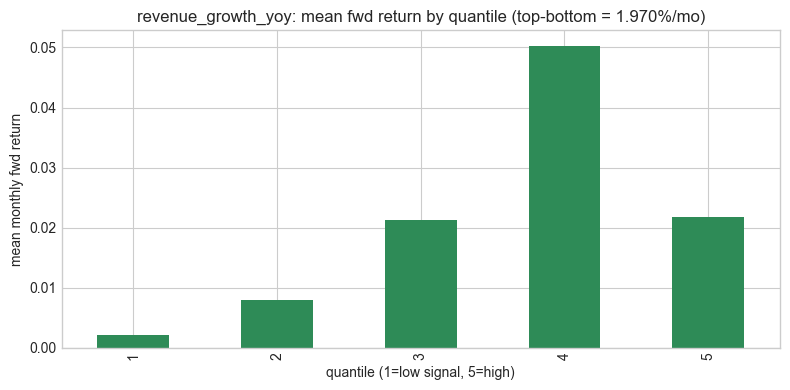

In [4]:
best = report.index[0]
qr = evaluate.quantile_returns(p, best, n_quantiles=5)
print(f'Best signal by IC IR: {best}')
spread = qr.loc['top_minus_bottom', 'mean_fwd_return'] if 'top_minus_bottom' in qr.index else float('nan')

fig, ax = plt.subplots(figsize=(8, 4))
qr.drop('top_minus_bottom', errors='ignore')['mean_fwd_return'].plot.bar(ax=ax, color='seagreen')
ax.set_title(f'{best}: mean fwd return by quantile (top-bottom = {spread:.3%}/mo)')
ax.set_xlabel('quantile (1=low signal, 5=high)'); ax.set_ylabel('mean monthly fwd return')
plt.tight_layout(); plt.show()

## Notes

- Mean IC of 0.03-0.05 for a single signal is genuinely useful at scale (`IR ≈ IC × √breadth`).
- The ML model (stage 4) should combine signals to lift IC above any single one.
- **Next**: `notebooks/04_model_ic.ipynb` — walk-forward ML ranking.